In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

import torch as ch
from torch import sigmoid as sig
from torch.distributions import MultivariateNormal
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from sklearn.linear_model import LogisticRegression

from delphi.utils.helpers import logistic
from torch.distributions.gumbel import Gumbel
from delphi.grad import TruncatedBCE, TruncatedCE

In [2]:
gumbel = Gumbel(0, 1)

In [3]:
class TruncatedCE_contained(ch.autograd.Function):
    @staticmethod
    def forward(ctx, pred, targ, phi, num_samples=100, eps=1e-5):
        """
        Args: 
            pred (torch.Tensor): size (batch_size, 1) matrix for regression model predictions
            targ (torch.Tensor): size (batch_size, 1) matrix for regression target predictions
            phi (oracle.oracle): dependent variable membership oracle
            num_samples (int): number of samples to generate per sample in batch in rejection sampling procedure
            eps (float): denominator error constant to avoid divide by zero errors
        """  
        stacked = pred[None, ...].repeat(num_samples, 1, 1)
        rand_noise = gumbel.sample(stacked.size())
        noised = stacked + rand_noise
        noised_labs = noised.argmax(-1, keepdim=True)
        filtered = phi(noised)
        mask = (noised_labs).eq(targ)
        filtered = filtered.float()
        ctx.save_for_backward(mask, filtered, rand_noise, pred)
        ctx.eps = eps
        prob_est = (mask * filtered + eps).sum(0) / (filtered.sum(0) + eps)
        return -ch.log(prob_est) / pred.size(0)
        
    @staticmethod
    def backward(ctx, grad_output):  
        mask, filtered, rand_noise, pred = ctx.saved_tensors
        inner_exp = (1 - ch.exp(-rand_noise))
        nll = ((inner_exp * mask * filtered).sum(0) / ((mask * filtered).sum(0) + ctx.eps))
        const = ((inner_exp * filtered).sum(0) / (filtered.sum(0) + ctx.eps))
        return (-nll + const) / pred.size(0), None, None, None, None

In [4]:
class TruncatedBCE(ch.autograd.Function):
    """
    Truncated binary cross entropy gradient for truncated binary classification tasks. 
    """
    @staticmethod
    def forward(ctx, pred, targ, phi, num_samples=1000, eps=1e-5):
        """
        Args: 
            pred (torch.Tensor): size (batch_size, 1) matrix for regression model predictions
            targ (torch.Tensor): size (batch_size, 1) matrix for regression target predictions
            phi (oracle.oracle): dependent variable membership oracle
            num_samples (int): number of samples to generate per sample in batch in rejection sampling procedure
            eps (float): denominator error constant to avoid divide by zero errors
        """  
        stacked = pred[None, ...].repeat(num_samples, 1, 1)
        rand_noise = logistic.sample(stacked.size())
        # add noise
        noised = stacked + rand_noise
        noised_labs = noised >= 0
        # filter
        filtered = phi(noised)
        mask = (noised_labs).eq(targ)
        filtered = filtered.float()
        ctx.save_for_backward(mask, filtered, rand_noise)
        ctx.eps = eps
        prob_est = (mask * filtered + eps).sum(0) / (filtered.sum(0) + ctx.eps)
        return -ch.log(prob_est) / pred.size(0)

    @staticmethod
    def backward(ctx, grad_output):
        mask, filtered, rand_noise = ctx.saved_tensors

        avg = 2*(sig(rand_noise) * mask * filtered).sum(0) / ((mask * filtered).sum(0) + ctx.eps) 
        norm_const = (2 * sig(rand_noise) * filtered).sum(0) / (filtered.sum(0) + ctx.eps)
        return -(avg - norm_const) / rand_noise.size(1), None, None, None, None

In [5]:
from torch.nn import CrossEntropyLoss

ce_loss = CrossEntropyLoss()

In [55]:
def trunc_logistic_mle(pred, targ, phi, seed=69): 
    if seed is not None:
        ch.manual_seed(seed)
    loss = TruncatedBCE.apply(pred, targ, phi)
    loss = loss.sum(0)
    loss.backward()
    return loss, pred.grad

def trunc_gumbel_mle(pred, targ, phi, seed=69, loss_fn=TruncatedCE): 
    if seed is not None:
        ch.manual_seed(seed)
    import pdb; pdb.set_trace()
    loss = loss_fn.apply(pred, targ, phi, 1000)
    loss = loss.sum(0)[...,None]
    loss.backward()
    return loss, pred.grad

# Untruncated Multinomial Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression

D, K = 1, 2

W = ch.ones(K, D)

print(f'groud truth W:\n {W}')

G = Gumbel(0, 1)

NUM_SAMPLES = 5000
X = ch.rand(NUM_SAMPLES, D)
print(f'ground truth num samples: {X.size(0)}')

Z = X @ W.T + G.sample([NUM_SAMPLES, K])

Y = Z.argmax(-1)

log_reg = LogisticRegression(penalty=None, fit_intercept=False)
log_reg.fit(X, Y)

gt_w = ch.from_numpy(log_reg.coef_)

print(f'fitted w: {gt_w}')

groud truth W:
 tensor([[1.],
        [1.]])
ground truth num samples: 5000
fitted w: tensor([[-0.0262]], dtype=torch.float64)


In [36]:
def phi(z): 
    z_diff = (z[...,0] - z[...,1])[...,None]
    return ch.ones_like(z_diff)

def phi_bce(z): 
    return ch.ones_like(z)

In [37]:
trunc_indices = phi(Z).flatten().nonzero().flatten()
X_trunc, Z_trunc = X[trunc_indices], Z[trunc_indices]
Y_trunc = Y[trunc_indices]
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

trunc_log_reg = LogisticRegression(penalty=None,fit_intercept=False)
trunc_log_reg.fit(X_trunc, Y_trunc)

trunc_w = ch.from_numpy(trunc_log_reg.coef_)

print(f'trunc fitted w: {trunc_w}')

alpha: 1.0
trunc fitted w: tensor([[-0.0262]], dtype=torch.float64)


<IPython.core.display.Javascript object>


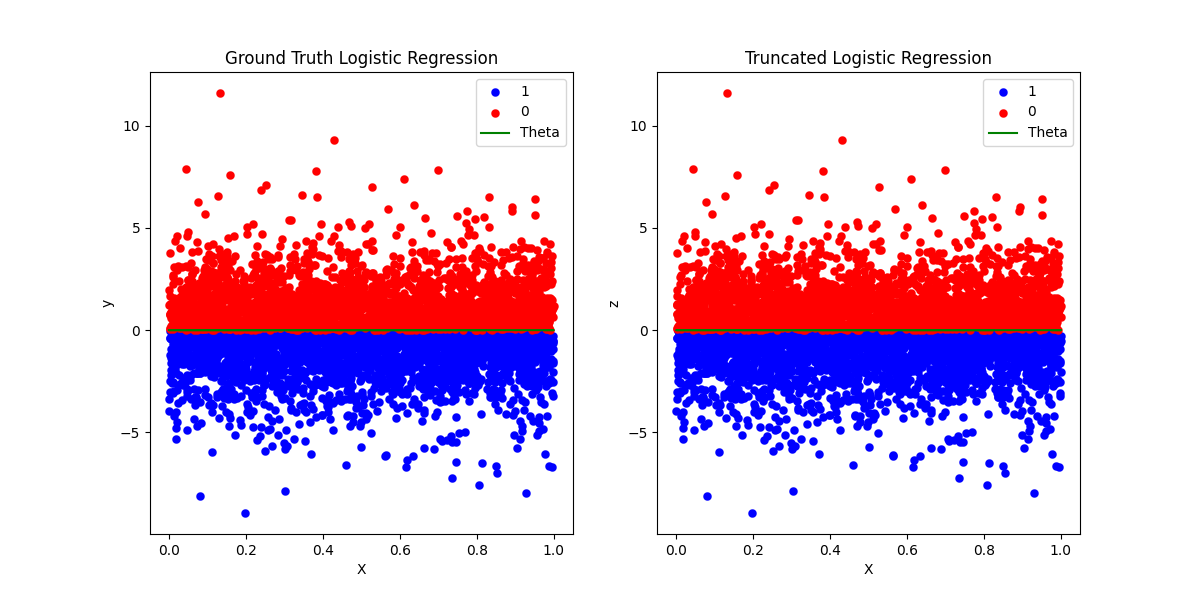

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ones = Y.flatten().nonzero().flatten()
zeros = (~Y.bool().flatten()).nonzero().flatten()

Z_zeros = Z[zeros]
Z_ones = Z[ones]

Z_zero_diff = Z_zeros[:,0] - Z_zeros[:,1]
Z_one_diff = Z_ones[:,0] - Z_ones[:,1]

ax1.scatter(X[ones], Z_one_diff, linewidths=.1, color='blue', label='1')
ax1.scatter(X[zeros], Z_zero_diff, linewidths=.1, color='red', label='0')
X_sorted = X.sort()[0]
pred = log_reg.predict(X_sorted)
ax1.plot(X_sorted, pred, color='green', label='Theta')
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.set_title('Ground Truth Logistic Regression')
ax1.legend()

trunc_ones = Y_trunc.flatten().nonzero().flatten()
trunc_zeros = (~Y_trunc.bool().flatten()).nonzero().flatten()

Z_trunc_ones = Z_trunc[trunc_ones]
Z_trunc_zeros = Z_trunc[trunc_zeros]

Z_trunc_zero_diff = Z_trunc_zeros[:,0] - Z_trunc_zeros[:,1]
Z_trunc_one_diff = Z_trunc_ones[:,0] - Z_trunc_ones[:,1] 

ax2.scatter(X_trunc[trunc_ones], Z_trunc_one_diff, linewidths=.1, color='blue', label='1')
ax2.scatter(X_trunc[trunc_zeros], Z_trunc_zero_diff, linewidths=.1, color='red', label='0')
trunc_pred = trunc_log_reg.predict(X_sorted)
ax2.plot(X_sorted, trunc_pred, color='green', label='Theta')
ax2.set_xlabel('X')
ax2.set_ylabel('z')
ax2.set_title('Truncated Logistic Regression')
ax2.legend()
plt.show()

In [39]:
from torch.nn import BCEWithLogitsLoss

In [ ]:
bce = BCEWithLogitsLoss()


ws = ch.linspace(-3, 5, 10)

losses = ch.Tensor([])
grads = ch.Tensor([])

trunc_bce_losses = ch.Tensor([])
trunc_bce_grads = ch.Tensor([])

bce_losses = ch.Tensor([])
bce_grads = ch.Tensor([])

ce_losses = ch.Tensor([])
ce_grads = ch.Tensor([])

for w in ws: 
    for w_ in ws:
        W_ = ch.cat([w[...,None], w_[...,None]])[None,...]
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_bce = bce(pred[:,1] - pred[:,0], Y_trunc.float())
        loss_bce.backward()
        bce_losses = ch.cat([bce_losses, loss_bce[...,None].detach()])
        bce_grads = ch.cat([bce_grads, X_trunc.T@pred.grad])
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_trunc_bce, pred_grad = trunc_logistic_mle((pred[:,1] - pred[:,0])[...,None], Y_trunc.float()[...,None], phi_bce)
        trunc_bce_losses = ch.cat([trunc_bce_losses, loss_trunc_bce[...,None].detach()])
        trunc_bce_grads = ch.cat([trunc_bce_grads, X_trunc.T@pred.grad])
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_ce = ce_loss(pred, Y_trunc.long())
        loss_ce.backward()
        ce_losses = ch.cat([ce_losses, loss_ce[...,None].detach()])
        ce_grads = ch.cat([ce_grads, X_trunc.T@pred.grad])
        
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss, pred_grad = trunc_gumbel_mle(pred, Y_trunc[...,None], phi)
        losses = ch.cat([losses, loss[...,None].detach()])
        grads = ch.cat([grads, X_trunc.T@pred_grad])

> /tmp/ipykernel_93019/548957476.py(13)trunc_gumbel_mle()
     11         ch.manual_seed(seed)
     12     import pdb; pdb.set_trace()
---> 13     loss = loss_fn.apply(pred, targ, phi, 1000)
     14     loss = loss.sum(0)[...,None]
     15     loss.backward()



/tmp/ipykernel_93019/548957476.py:7: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  return loss, pred.grad


ipdb> p pred.size()
torch.Size([5000, 2])


In [53]:
losses = losses.flatten()

<IPython.core.display.Javascript object>


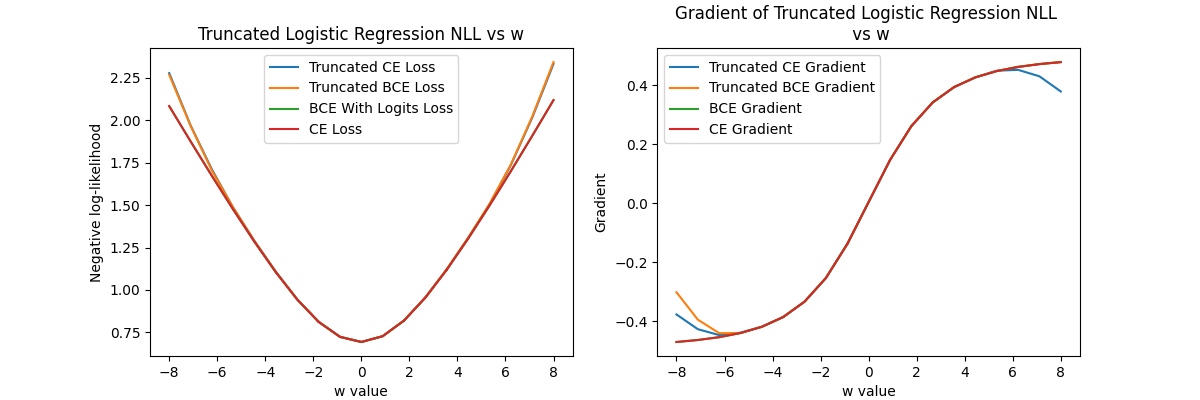

In [54]:
WS_ = ch.Tensor([])

for w_ in ws: 
    for w__ in ws: 
        WS_ = ch.cat([WS_, ch.cat([w_[...,None], w__[...,None]])[None,...]])

w_diffs = WS_[:,1] - WS_[:,0]

w_sorted, indices = w_diffs.sort()

# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(w_sorted, losses[indices], label="Truncated CE Loss")
ax1.plot(w_sorted, trunc_bce_losses[indices], label="Truncated BCE Loss")
ax1.plot(w_sorted, bce_losses[indices], label="BCE With Logits Loss")
ax1.plot(w_sorted, ce_losses[indices], label="CE Loss")

ax1.set_xlabel("w value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Logistic Regression NLL vs w")
ax1.legend()

ax2.plot(w_sorted, grads[:,1][indices] - grads[:,0][indices], label="Truncated CE Gradient")
ax2.plot(w_sorted, trunc_bce_grads[:,1][indices] - trunc_bce_grads[:,0][indices], label="Truncated BCE Gradient")
ax2.plot(w_sorted, bce_grads[:,1][indices] - bce_grads[:,0][indices], label="BCE Gradient")
ax2.plot(w_sorted, ce_grads[:,1][indices] - ce_grads[:,0][indices], label="CE Gradient")


ax2.set_xlabel("w value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Logistic Regression NLL \n vs w")
ax2.legend()

plt.show()

#  Truncated Multinomial Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

D, K = 1, 2

W = ch.ones(K, D)

print(f'groud truth W:\n {W}')

G = Gumbel(0, 1)

NUM_SAMPLES = 5000
X = ch.rand(NUM_SAMPLES, D)
print(f'ground truth num samples: {X.size(0)}')

Z = X @ W.T + G.sample([NUM_SAMPLES, K])

Y = Z.argmax(-1)

log_reg = LogisticRegression(penalty=None, fit_intercept=False)
log_reg.fit(X, Y)

gt_w = ch.from_numpy(log_reg.coef_)

print(f'fitted w: {gt_w}')

groud truth W:
 tensor([[1.],
        [1.]])
ground truth num samples: 5000
fitted w: tensor([[0.0191]], dtype=torch.float64)


In [16]:
def phi(z): 
    z_diff = (z[...,1] - z[...,0])[...,None]
    return z_diff > -.25

def phi_bce(z): 
    return z > -.25

In [17]:
trunc_indices = phi(Z).flatten().nonzero().flatten()
X_trunc, Z_trunc = X[trunc_indices], Z[trunc_indices]
Y_trunc = Y[trunc_indices]
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

trunc_log_reg = LogisticRegression(penalty=None,fit_intercept=False)
trunc_log_reg.fit(X_trunc, Y_trunc)

trunc_w = ch.from_numpy(trunc_log_reg.coef_)

print(f'trunc fitted w: {trunc_w}')

alpha: 0.5608
trunc fitted w: tensor([[3.4588]], dtype=torch.float64)


<IPython.core.display.Javascript object>


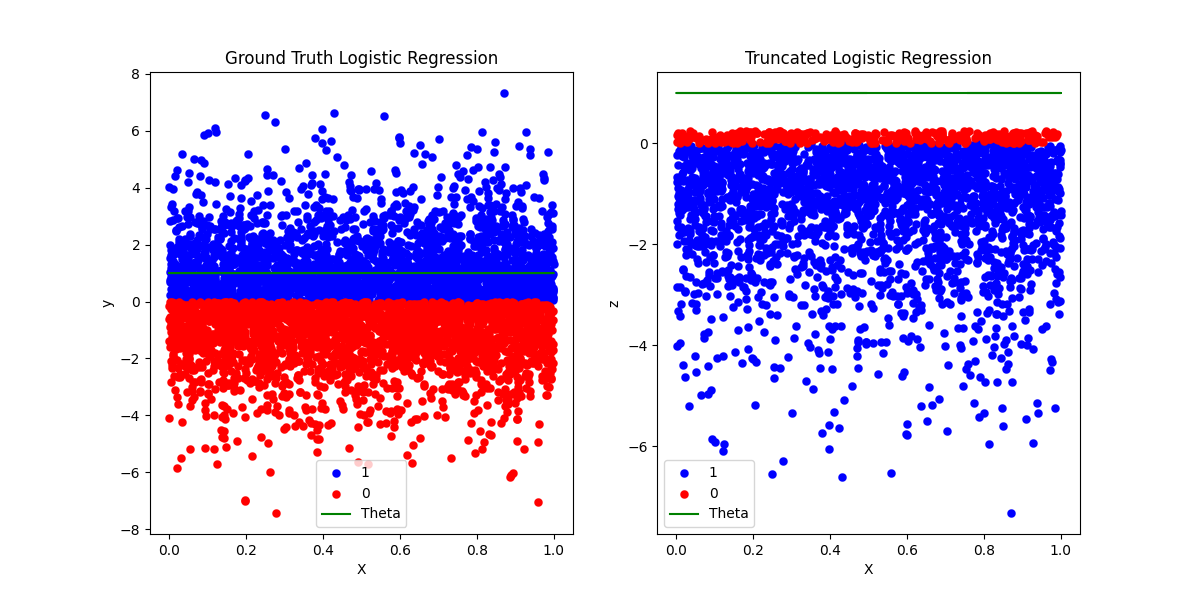

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ones = Y.flatten().nonzero().flatten()
zeros = (~Y.bool().flatten()).nonzero().flatten()

Z_zeros = Z[zeros]
Z_ones = Z[ones]

Z_zero_diff = Z_zeros[:,1] - Z_zeros[:,0]
Z_one_diff = Z_ones[:,1] - Z_ones[:,0]

ax1.scatter(X[ones], Z_one_diff, linewidths=.1, color='blue', label='1')
ax1.scatter(X[zeros], Z_zero_diff, linewidths=.1, color='red', label='0')
X_sorted = X.sort()[0]
pred = log_reg.predict(X_sorted)
ax1.plot(X_sorted, pred, color='green', label='Theta')
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.set_title('Ground Truth Logistic Regression')
ax1.legend()

trunc_ones = Y_trunc.flatten().nonzero().flatten()
trunc_zeros = (~Y_trunc.bool().flatten()).nonzero().flatten()

Z_trunc_ones = Z_trunc[trunc_ones]
Z_trunc_zeros = Z_trunc[trunc_zeros]

Z_trunc_zero_diff = Z_trunc_zeros[:,0] - Z_trunc_zeros[:,1]
Z_trunc_one_diff = Z_trunc_ones[:,0] - Z_trunc_ones[:,1] 

ax2.scatter(X_trunc[trunc_ones], Z_trunc_one_diff, linewidths=.1, color='blue', label='1')
ax2.scatter(X_trunc[trunc_zeros], Z_trunc_zero_diff, linewidths=.1, color='red', label='0')
trunc_pred = trunc_log_reg.predict(X_sorted)
ax2.plot(X_sorted, trunc_pred, color='green', label='Theta')
ax2.set_xlabel('X')
ax2.set_ylabel('z')
ax2.set_title('Truncated Logistic Regression')
ax2.legend()
plt.show()

In [19]:
bce = BCEWithLogitsLoss()

ws = ch.linspace(-3, 5, 10)

losses = ch.Tensor([])
grads = ch.Tensor([])

trunc_bce_losses = ch.Tensor([])
trunc_bce_grads = ch.Tensor([])

bce_losses = ch.Tensor([])
bce_grads = ch.Tensor([])

ce_losses = ch.Tensor([])
ce_grads = ch.Tensor([])

for w in ws: 
    for w_ in ws:
        W_ = ch.cat([w[...,None], w_[...,None]])[None,...]
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_bce = bce(pred[:,1] - pred[:,0], Y_trunc.float())
        loss_bce.backward()
        bce_losses = ch.cat([bce_losses, loss_bce[...,None].detach()])
        bce_grads = ch.cat([bce_grads, X_trunc.T@pred.grad])
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_trunc_bce, pred_grad = trunc_logistic_mle((pred[:,1] - pred[:,0])[...,None], Y_trunc.float()[...,None], phi_bce)
        trunc_bce_losses = ch.cat([trunc_bce_losses, loss_trunc_bce[...,None].detach()])
        trunc_bce_grads = ch.cat([trunc_bce_grads, X_trunc.T@pred.grad])
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_ce = ce_loss(pred, Y_trunc.long())
        loss_ce.backward()
        ce_losses = ch.cat([ce_losses, loss_ce[...,None].detach()])
        ce_grads = ch.cat([ce_grads, X_trunc.T@pred.grad])
        
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss, pred_grad = trunc_gumbel_mle(pred, Y_trunc, phi)
        losses = ch.cat([losses, loss[...,None].detach()])
        grads = ch.cat([grads, X_trunc.T@pred_grad])

/tmp/ipykernel_85219/585968354.py:7: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  return loss, pred.grad


In [20]:
losses = losses.flatten()

<IPython.core.display.Javascript object>


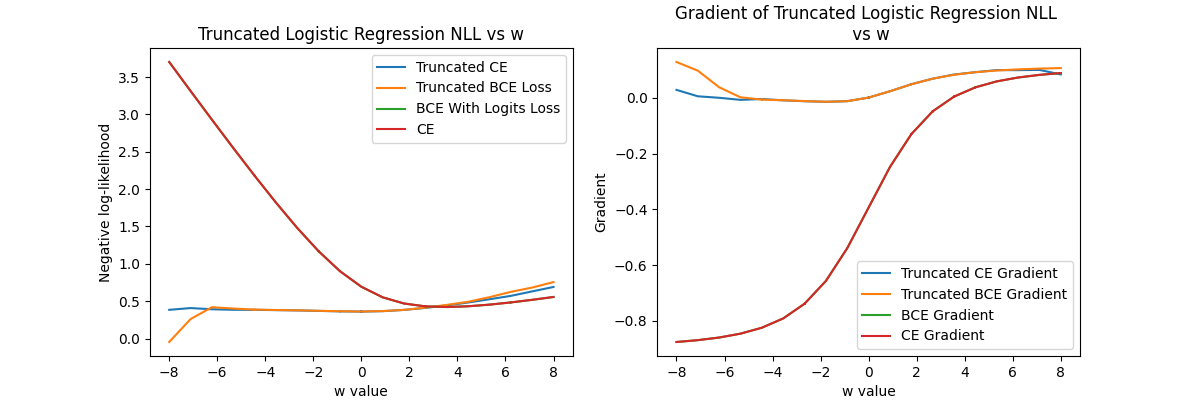

In [21]:
WS_ = ch.Tensor([])

for w_ in ws: 
    for w__ in ws: 
        WS_ = ch.cat([WS_, ch.cat([w_[...,None], w__[...,None]])[None,...]])

w_diffs = WS_[:,1] - WS_[:,0]

w_sorted, indices = w_diffs.sort()

# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(w_sorted, losses[indices], label="Truncated CE")
ax1.plot(w_sorted, trunc_bce_losses[indices], label="Truncated BCE Loss")
ax1.plot(w_sorted, bce_losses[indices], label="BCE With Logits Loss")
ax1.plot(w_sorted, ce_losses[indices], label="CE")

ax1.set_xlabel("w value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Logistic Regression NLL vs w")
ax1.legend()

ax2.plot(w_sorted, grads[:,1][indices] - grads[:,0][indices], label="Truncated CE Gradient")
ax2.plot(w_sorted, trunc_bce_grads[:,1][indices] - trunc_bce_grads[:,0][indices], label="Truncated BCE Gradient")
ax2.plot(w_sorted, bce_grads[:,1][indices] - bce_grads[:,0][indices], label="BCE Gradient")
ax2.plot(w_sorted, ce_grads[:,1][indices] - ce_grads[:,0][indices], label="CE Gradient")


ax2.set_xlabel("w value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Logistic Regression NLL \n vs w")
ax2.legend()

plt.show()

In [7]:
from torch.distributions import Uniform

d, k = 1, 2
# ground-truth logistic regression model 
w = Uniform(-1, 1)
U = Uniform(-5, 5)
W = w.sample([k, d])
print(f'ground truth: {W}')
print(f'effective ground truth: {W[1] - W[0]}')

# input features
SAMPLES = 10000
X = U.sample([SAMPLES, d])
# latent variables
z = X@W.T + gumbel.sample([X.size(0), k])
# classification
y = z.argmax(-1)

ground truth: tensor([[-0.1163],
        [ 0.7777]])
effective ground truth: tensor([0.8940])


In [8]:
from sklearn.metrics import confusion_matrix

sklearn = LogisticRegression(penalty=None, verbose=10, fit_intercept=False)
sklearn.fit(X, y.flatten())
sklearn_ = ch.from_numpy(sklearn.coef_)

print(f'sklearn: {sklearn_}')
pred = sklearn.predict(X)
acc = np.equal(pred, y.flatten()).sum() / len(y)
print(f'sklearn acc: {acc}')
sklearn_conf_matrix = confusion_matrix(y, pred)
print(f'sklearn confusion matrix: \n {sklearn_conf_matrix}')

sklearn: tensor([[0.9014]], dtype=torch.float64)
sklearn acc: 0.8513000011444092
sklearn confusion matrix: 
 [[4294  751]
 [ 736 4219]]


[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
/tmp/ipykernel_93019/3637359842.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  acc = np.equal(pred, y.flatten()).sum() / len(y)


In [9]:
def phi(z): 
    return ch.ones(z.size(-2), 1)

trunc_indices = phi(z).flatten().nonzero().flatten() 
X_trunc, Y_trunc = X[trunc_indices], y[trunc_indices][...,None]
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

alpha: 1.0


In [23]:
from delphi.stats.truncated_logistic_regression import TruncatedLogisticRegression
from delphi.utils.helpers import Parameters

emp_weight = ch.randn(W.size())
args = Parameters({
                    'batch_size': 5000,
                    'epochs': 10,
                    'trials': 1,
                    'verbose': True,
                    'early_stopping': True,
                    'num_samples': 5000,
                })        
delphi_log_reg = TruncatedLogisticRegression(args,
                                            phi, 
                                            alpha, 
                                            fit_intercept=False,
                                            multi_class="multinomial", 
                                            emp_weight=emp_weight)
delphi_log_reg.fit(X_trunc, Y_trunc)

trial: 1
Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': False}
loss: tensor([0.8169], grad_fn=<SumBackward1>)
loss: tensor([0.0429], grad_fn=<SumBackward1>)
loss: tensor([-0.4505])
Epoch 1 - Loss: -0.4505208134651184
loss: tensor([0.4609], grad_fn=<SumBackward1>)
loss: tensor([-0.0987], grad_fn=<SumBackward1>)
loss: tensor([-0.5130])
Epoch 2 - Loss: -0.513027548789978
loss: tensor([0.3958], grad_fn=<SumBackward1>)
loss: tensor([-0.1348], grad_fn=<SumBackward1>)
loss: tensor([-0.5340])
Epoch 3 - Loss: -0.5339611172676086
loss: tensor([0.3674], grad_fn=<SumBackward1>)
loss: tensor([-0.1408], grad_fn=<SumBackward1>)
loss: tensor([-0.5431])
Epoch 4 - Loss: -0.5431187152862549
loss: tensor([0.3550], grad_fn=<SumBackward1>)
loss: tensor([-0.1452], grad_fn=<SumBackward1>)
loss: tensor([-0.5481])
Epoch 5 - Loss: -0.5480940341949463
Convergence after 5 epochs took 7.66 seconds


TruncatedLogisticRegression()

In [24]:
from torch.nn import CosineSimilarity
cos_sim = CosineSimilarity()

delphi_log_reg_ = delphi_log_reg.coef_                
print(f'delphi log reg: {delphi_log_reg_}')
delphi_diff_ = delphi_log_reg_[:,1] - delphi_log_reg_[:,0]
delphi_cos_sim = float(cos_sim(delphi_diff_[None,...], sklearn_))
delphi_pred = delphi_log_reg.predict(X)
delphi_acc = delphi_pred.eq(y).sum() / len(y)
print(f'delphi accuracy: {delphi_acc}')
print(f'delphi cos sim: {delphi_cos_sim}')
delphi_conf_matrix = confusion_matrix(y[...,None], delphi_pred)
print(f'delphi confusion matrix: \n {delphi_conf_matrix}')

delphi log reg: tensor([[0.1676, 0.8603]])
delphi accuracy: 0.6930000185966492
delphi cos sim: 1.0
delphi confusion matrix: 
 [[4985   60]
 [3010 1945]]


In [25]:
delphi_diff = (delphi_log_reg.trainer.param_history[:,1] - delphi_log_reg.trainer.param_history[:,0])[...,None]

In [26]:
min_ = delphi_log_reg.trainer.param_history[delphi_log_reg.trainer.loss_history.argmin()]
min_

tensor([0.1676, 0.8603])

In [27]:
min_[1] - min_[0]

tensor(0.6928)

In [28]:
ws = ch.linspace(-.5, 1.0, 5)
WS_ = ch.Tensor([])

for w_ in ws: 
    for w__ in ws: 
        WS_ = ch.cat([WS_, ch.cat([w_[...,None], w__[...,None]])[None,...]])

w_diffs = WS_[:,1] - WS_[:,0]

w_sorted, indices = w_diffs.sort()

In [29]:
WS_.requires_grad = True
losses_contained = ch.Tensor([trunc_gumbel_mle(X@ws_[None,...], y[...,None], phi)[0].detach().item() for ws_  in WS_])
losses = ch.Tensor([trunc_gumbel_mle(X@ws_[None,...], y[...,None], phi, loss_fn=TruncatedCE)[0].detach().item() for ws_  in WS_])

/tmp/ipykernel_93019/4087560840.py:15: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  return loss, pred.grad


In [30]:
losses

tensor([5.3033, 5.0376, 4.9611, 4.9828, 5.0548, 5.8517, 5.3033, 5.0376, 4.9611,
        4.9828, 6.6779, 5.8517, 5.3033, 5.0376, 4.9611, 8.2414, 6.6779, 5.8517,
        5.3033, 5.0376, 9.7626, 8.2414, 6.6779, 5.8517, 5.3033])

<IPython.core.display.Javascript object>


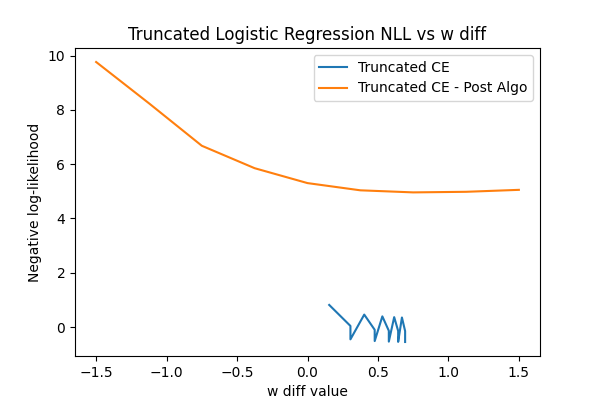

In [33]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))

ax1.plot(delphi_diff.detach(), delphi_log_reg.trainer.loss_history, label="Truncated CE")
ax1.plot(w_diffs[indices], losses[indices], label="Truncated CE - Post Algo")
# ax1.plot(w_diffs[indices], losses_contained[indices], label="Truncated CE Contained")

# ax.plot(w_sorted, trunc_bce_losses[indices], label="Truncated BCE Loss")
# ax.plot(w_sorted, bce_losses[indices], label="BCE With Logits Loss")
# ax.plot(w_sorted, ce_losses[indices], label="CE")

ax1.set_xlabel("w diff value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Logistic Regression NLL vs w diff")
ax1.legend()


plt.show()

In [19]:
param_history = delphi_log_reg.trainer.param_history

param_history_diff = param_history[:,1] - param_history[:,0]

In [20]:
X_val, y_val = delphi_log_reg.val_loader.dataset.tensors

In [21]:
param_history.requires_grad = True
losses_param_history_contained = ch.Tensor([trunc_gumbel_mle(X_val@ws_[None,...], y_val, phi)[0].detach().item() for ws_  in param_history])
losses_param_history = ch.Tensor([trunc_gumbel_mle(X_val@ws_[None,...], y_val, phi, loss_fn=TruncatedCE)[0].detach().item() for ws_  in param_history])


/tmp/ipykernel_93019/4087560840.py:15: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  return loss, pred.grad


<IPython.core.display.Javascript object>


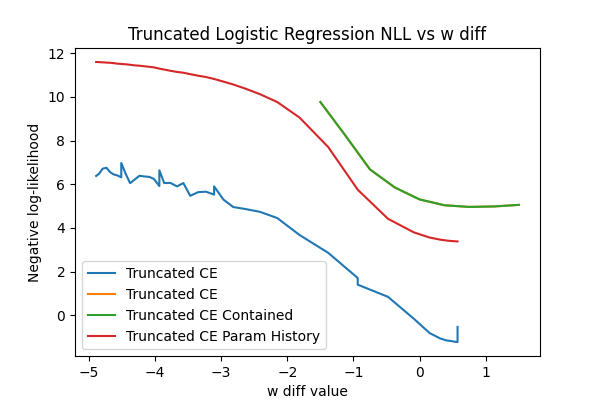

In [22]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))

ax1.plot(delphi_diff.detach(), delphi_log_reg.trainer.loss_history.detach(), label="Truncated CE")
ax1.plot(w_diffs[indices], losses[indices], label="Truncated CE")
ax1.plot(w_diffs[indices], losses_contained[indices], label="Truncated CE Contained")
ax1.plot(param_history_diff.detach(), losses_param_history, label="Truncated CE Param History")


# ax.plot(w_sorted, trunc_bce_losses[indices], label="Truncated BCE Loss")
# ax.plot(w_sorted, bce_losses[indices], label="BCE With Logits Loss")
# ax.plot(w_sorted, ce_losses[indices], label="CE")

ax1.set_xlabel("w diff value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Logistic Regression NLL vs w diff")
ax1.legend()


plt.show()

In [ ]:
args.batch_size

In [48]:
WS_[indices][0, 1] - WS_[indices][0, 0]

tensor(-8.)

In [42]:
((X_val@param_history[0][None,...] + gumbel.sample([X_val.size(0), 2])).argmax(-1, keepdim=True) == y_val).sum() / y_val.size(0)

tensor(0.6210)

In [43]:
losses_param_history_contained

tensor([3.5039, 3.4692, 3.4535, 3.4446, 3.4379, 3.4339, 3.4305, 3.4292, 3.4292,
        3.4270, 3.4262, 3.4256, 3.4247, 3.4247, 3.4247, 3.4250, 3.4250, 3.4250,
        3.4247, 3.4283, 3.4287, 3.4287, 3.4286, 3.4286, 3.4281, 3.4281, 3.4281,
        3.4281, 3.4283, 3.4283, 3.4281, 3.4285, 3.4287, 3.4282, 3.4282, 3.4282,
        3.4283, 3.4285, 3.4283, 3.4284, 3.4282, 3.4286, 3.4283, 3.4284, 3.4284])

In [44]:
losses_param_history

tensor([3.5039, 3.4692, 3.4535, 3.4446, 3.4379, 3.4339, 3.4305, 3.4292, 3.4292,
        3.4270, 3.4262, 3.4256, 3.4247, 3.4247, 3.4247, 3.4250, 3.4250, 3.4250,
        3.4247, 3.4283, 3.4287, 3.4287, 3.4286, 3.4286, 3.4281, 3.4281, 3.4281,
        3.4281, 3.4283, 3.4283, 3.4281, 3.4285, 3.4287, 3.4282, 3.4282, 3.4282,
        3.4283, 3.4285, 3.4283, 3.4284, 3.4282, 3.4286, 3.4283, 3.4284, 3.4284])